In [1]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index
from utils import e_r_cpa_numerator, e_r_cpa, h_r_cpa, hl2, hl2prime, hl1, hl1prime

from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
from numpy import sqrt, heaviside, pi

### In the code below, we require the product of the longitudinal wavenumber, $k_{nl}$, with the radius of the nanosphere, $R$. We express the result as a function of $x\equiv R\omega/c$ and $\omega/\omega_p$, which we just write as $\omega$, and $\beta_F/c$, which we just write as $\beta_F$ and $\gamma/\omega_p$, which we just write as $\gamma$. The longitudinal wavevector may be written as follows: 
$k^2_{nl}=\frac{1}{\beta_F^2}(\omega^2+i\omega\gamma-\omega_p^2)=\frac{\omega_p^2}{\beta_F^2}\frac{\varepsilon_m}{1-\varepsilon_m}\rightarrow k^2_{nl}R^2=\frac{\omega_p^2 c^2}{\beta_F^2\omega^2}\frac{\varepsilon_m}{1-\varepsilon_m}(R\omega/c)^2$
### Note that the Drude permittivity of the material may, of course, be written as a function of $\omega/\omega_p$ and $\gamma/\omega_p$.

### To justify the resonance frequencies we find below, we note that the bulk plasmon frequencies will be given by the following expression (see Eq. (9) of [Nonlocal Response of Metallic Nanospheres Probed by Light, Electrons, and Atoms](https://pubs.acs.org/ancac3/article-pdf/8/2/1745/13770781/nn406153k.pdf):

$\omega^2 = \omega_p^2 + w_{ln}^2\beta_F^2/R^2,$ 

### where $w_{ln}$ is the $n$'th zero of the derivative of the Riccati-Bessel function of order $l$.

### We may rewrite this dispersion relation as $1=(\omega_p/\omega)^2 + w_{ln}^2(\beta_F/c)^2c^2/(R\omega)^2$. Furthermore, by using the nondimensionalized $\omega$, we may rewrite this as follows: 
$\begin{align*}
1=\frac{1}{\omega^2}+w_{ln}^2\frac{\beta_F^2}{x^2} \rightarrow \omega^2 = \frac{1}{1-w_{ln}^2\frac{\beta_F^2}{x^2}}
\end{align*}$

### In the cell below, we find the (approximate) frequency of the first resonance. 

In [2]:
x = 2 # R*omega/c
beta = 5e-2 # In units of the speed of light
wln = 2.744 # Approximate first zero of the derivative of the Riccati-Bessel function (of order unity)
sqrt(1/(1-wln**2*beta/x**2)).item()

1.0506655016191733

### The functions below calculate the nonlocal TM scattering coefficient (see Eq. (4b) of the paper [Nonlocal Response of Metallic Nanospheres Probed by Light, Electrons, and Atoms](https://pubs.acs.org/ancac3/article-pdf/8/2/1745/13770781/nn406153k.pdf)). The only difference with the paper is that we consider the response to an incoming Hankel function as opposed to a partial wave. Note also that only the TM scattering coefficients change due to nonlocality (in this approximation). 

In [3]:
def e_r_cpa_numerator_hydrodynamic(l, x, omega, beta=5e-3, gamma=1e-1): # gamma and omega given in units of omega_p. beta given in units of the speed of light.
    epsilon = 1 - 1/(omega**2+1j*omega*gamma) # Drude dielectric funtion for epsilon_infinity = 1
    # Note that x = R*omega/c
    knl_sqrd = (epsilon/(1-epsilon))*(1/beta**2)*(1/omega**2)  
    knl = sqrt(knl_sqrd) # k_nl * R will be given by k_nl * x 
    m = sqrt(epsilon)
    y = x * m # transverse mode in the sphere
    z = x * knl # longitudinal mode
    xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
    yjl_prime = spherical_jn(l, y) + y * spherical_jn(l, y, derivative=True)
    delta = l*(l+1)*(epsilon-1)*spherical_jn(l, y)*(spherical_jn(l, z)/(z*spherical_jn(l, z, derivative=True)))
    return epsilon * spherical_jn(l, y) * xhl2_prime - (yjl_prime  + delta) * hl2(l, x) 

def e_r_cpa_denominator_hydrodynamic(l, x, omega, beta=5e-3, gamma=1e-1):  # gamma and omega given in units of omega_p. beta given in units of the speed of light.
    epsilon = 1 - 1/(omega**2+1j*omega*gamma) # Drude dielectric funtion for epsilon_infinity = 1
    knl_sqrd = (epsilon/(1-epsilon))*(1/beta**2)*(1/omega**2)
    knl = sqrt(knl_sqrd)
    m = sqrt(epsilon)
    y = x * m 
    z = x * knl

    xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
    yjl_prime = spherical_jn(l, y) + y * spherical_jn(l, y, derivative=True)
    delta = l*(l+1)*(epsilon-1)*spherical_jn(l, y)*(spherical_jn(l, z)/(z*spherical_jn(l, z, derivative=True)))
    return -epsilon * spherical_jn(l, y) * xhl1_prime + (yjl_prime + delta) * hl1(l, x) 

def e_r_cpa_hydrodynamic(l, x, omega, beta=5e-3, gamma=1e-1 ): 
    return e_r_cpa_numerator_hydrodynamic(l, x, omega, beta, gamma)/e_r_cpa_denominator_hydrodynamic(l, x, omega, beta, gamma)

In [4]:
N = 1000
omegas = linspace(1.15, 1.18, N)
s_sqrds = np.zeros(N)
s_sqrds_local = np.zeros(N)
x = 0.1
gamma = 1.6e-4 # 1e-5, beta = 5e-5
beta = 4e-2
for (omega_idx, omega) in enumerate(omegas):
    epsilon = 1 - 1/(omega**2+1j*omega*gamma)
    s_sqrds[omega_idx] = np.abs(e_r_cpa_hydrodynamic(1, x, omega, beta=beta, gamma=gamma))**2
    s_sqrds_local[omega_idx] = np.abs(e_r_cpa(1, x, epsilon))**2

Minimum nonlocal s squared:  0.0005944288595980421


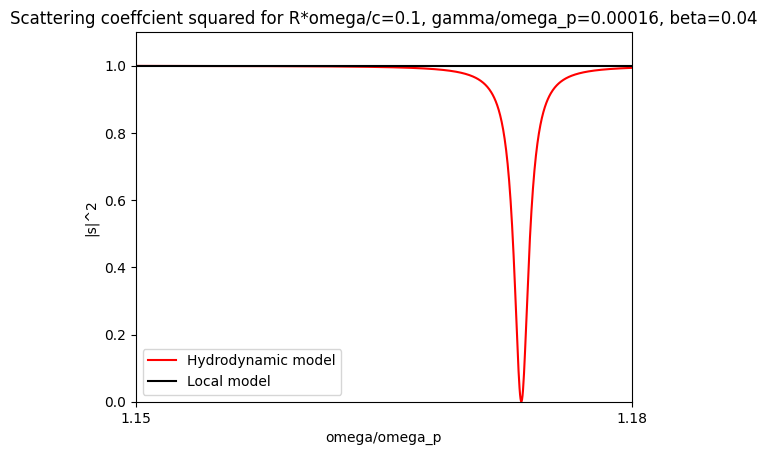

In [5]:
plt.plot(omegas, s_sqrds, color="red", label="Hydrodynamic model")
plt.plot(omegas, s_sqrds_local, color="black", label="Local model");
plt.xlim(omegas.min(), omegas.max())
plt.xticks([omegas.min(), omegas.max()])
plt.ylim(0, 1.1)
plt.ylabel("|s|^2")
plt.xlabel("omega/omega_p")
plt.legend();
plt.title(f"Scattering coeffcient squared for R*omega/c={x}, gamma/omega_p={gamma}, beta={beta}")
print("Minimum nonlocal s squared: ", s_sqrds.min())

### Now we do a sanity check of the code above with the figures of the paper: [Optical Properties of a Plasma Sphere](https://journals.aps.org/prl/pdf/10.1103/PhysRevLett.31.1434?casa_token=i4XsSfDjspgAAAAA%3AYS4tkcDAeioMpYUG7HSaBSL2jtNsEuF1K8cmvl91uQg02bC1aiPKCKGQBuKwZd3bnuo1-HUS_7rTnQ) by Ruppin. We use $\gamma/\omega_p=0.01$, $\omega_p=6.5\times 10^{15} \text{s}^{-1}$, $R=20\text{angstrom}$ and $v_F=8.52\times 10^{7}\text{cm}\times\text{s}^{-1}$, which are the parameters used in Fig. (1) of the paper. We first calculate $x\equiv R\omega/c$, which is given as follows: $R\omega/c=R(\omega_p/c)\times(\omega/\omega_p)=(6.5\times 20/3)\times 10^{-3}(\omega/\omega_p)\approx 0.0433(\omega/\omega_p)$ and then calculate the cross section using the formula in the Ruppin paper. 

In [6]:
gamma = 0.01 # Damping factor divided by plasma frequency 
v_F = (8.52/3) * 1e-3 # Fermi velocity divided by speed of light
beta_sqrd = (3/5)*v_F**2
beta = sqrt(beta_sqrd)
N = 10000
omegas = linspace(0.2, 1.55, N) # In unites of the plasma frequency (i.e. omega/omega_p)
xs = .0433 * omegas # Derived in the cell above
cross_sections_local = zeros(N)
cross_sections_non_local = zeros(N)
for l in range(1, 5):
    s_non_local_tm = e_r_cpa_hydrodynamic(l, xs, omegas, beta=beta, gamma=gamma)
    s_local_tm = e_r_cpa(l, xs, 1 - 1/(omegas**2+1j*omegas*gamma))
    s_te = h_r_cpa(l, xs, 1 - 1/(omegas**2+1j*omegas*gamma)) # Same for local and nonlocal
    
    cross_sections_non_local += (-2/xs**2)*(2*l+1)*((s_non_local_tm-1)/2).real
    cross_sections_local += (-2/xs**2)*(2*l+1)*((s_local_tm-1)/2).real
    cross_sections_non_local += (-2/xs**2)*(2*l+1)*((s_te-1)/2).real
    cross_sections_local += (-2/xs**2)*(2*l+1)*((s_te-1)/2).real

### Below is Figure 1 of the Ruppin paper 

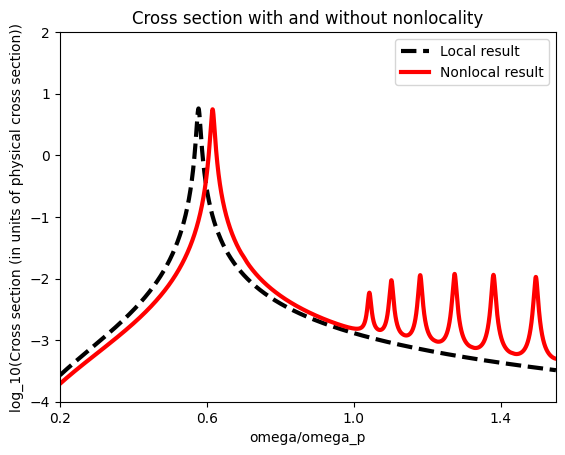

In [8]:
plt.plot(omegas, np.log10(cross_sections_local), color="black", linestyle="dashed", linewidth=3, label="Local result")
plt.plot(omegas, np.log10(cross_sections_non_local), color="red", linestyle="solid", linewidth=3, label="Nonlocal result")
plt.yticks([-4, -3, -2, -1, 0, 1, 2]);
plt.xlim(0.2, 1.55);
plt.legend();
plt.xticks([0.2, 0.6, 1.0, 1.4])
plt.xlabel("omega/omega_p")
plt.ylabel("log_10(Cross section (in units of physical cross section))");
plt.title("Cross section with and without nonlocality");
#plt.ylim(-3, -2);

### Now we plot Figure 2 of the Ruppin paper 

In [9]:
gamma = 0.01 # Damping factor divided by plasma frequency 
v_F = (8.52/3) * 1e-3 # Fermi velocity divided by speed of light
beta_sqrd = (3/5)*v_F**2
beta = sqrt(beta_sqrd)
N = 10000
omegas = linspace(0.2, 1.55, N) # In unites of the plasma frequency (i.e. omega/omega_p)
xs = .0433 * 5/2 * omegas # Derived in the cell above
cross_sections_local = zeros(N)
cross_sections_non_local = zeros(N)
for l in range(1, 5):
    s_non_local_tm = e_r_cpa_hydrodynamic(l, xs, omegas, beta=beta, gamma=gamma)
    s_local_tm = e_r_cpa(l, xs, 1 - 1/(omegas**2+1j*omegas*gamma))
    s_te = h_r_cpa(l, xs, 1 - 1/(omegas**2+1j*omegas*gamma)) # Same for local and nonlocal
    
    cross_sections_non_local += (-2/xs**2)*(2*l+1)*((s_non_local_tm-1)/2).real
    cross_sections_local += (-2/xs**2)*(2*l+1)*((s_local_tm-1)/2).real
    cross_sections_non_local += (-2/xs**2)*(2*l+1)*((s_te-1)/2).real
    cross_sections_local += (-2/xs**2)*(2*l+1)*((s_te-1)/2).real

### Below is Figure 2 of the Ruppin paper 

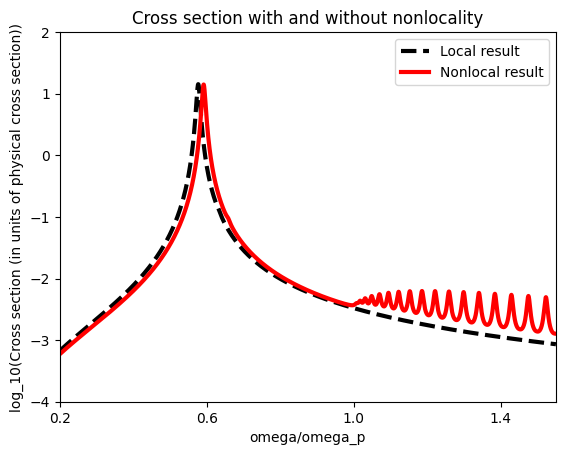

In [10]:
plt.plot(omegas, np.log10(cross_sections_local), color="black", linestyle="dashed", linewidth=3, label="Local result")
plt.plot(omegas, np.log10(cross_sections_non_local), color="red", linestyle="solid", linewidth=3, label="Nonlocal result")
plt.yticks([-4, -3, -2, -1, 0, 1, 2]);
plt.xlim(0.2, 1.55);
plt.xticks([0.2, 0.6, 1.0, 1.4])
plt.legend();
plt.xlabel("omega/omega_p")
plt.ylabel("log_10(Cross section (in units of physical cross section))");
plt.title("Cross section with and without nonlocality");
#plt.ylim(-3, -2);

### Now we try to reproduce Fig. (7a1) of the following paper: [Nonlocal Response of Metallic Nanospheres Probed by Light, Electrons, and Atoms](https://pubs.acs.org/ancac3/article-pdf/8/2/1745/13770781/nn406153k.pdf). Note that I don't believe that they give an explicit value for $v_F/c$, but they do give a value for the plasma frequency. For a free electron gas, these two are not independent quantities, so we calculate $v_F/c$ below using $\hbar\omega_p=10\text{eV}$

$\begin{align*}
\omega_p^2=\frac{n_0e^2}{m\varepsilon_0}=\frac{k_F^3}{3\pi^2}\frac{e^2}{m\varepsilon_0}=\frac{v_F^3}{3\pi^2\hbar^3}\frac{e^2 m^2}{\varepsilon_0}
\end{align*}$

### Thus, using $\alpha=1/137=e^2/(4\pi\varepsilon_0\hbar c) \rightarrow 4\alpha c = e^2/(\pi\varepsilon_0\hbar)$, we obtain the following:

$\begin{align*}
\omega_p^2 = \frac{4v_F^3 c m^2\alpha}{3\pi\hbar^2} \rightarrow (\hbar\omega_p)^2=\frac{4(v_F/c)^3 m^2 c^4\alpha}{3\pi} \approx \frac{4}{3\pi}(v_F/c)^3(0.511\times 10^6 \text{eV})^2\alpha \rightarrow v_F/c \approx ((300\times 137\pi/4)/(0.511\times 10^6)^2)^{1/3} \approx 4.98\times 10^{-3}
\end{align*}$

### Furthermore, note that $R\omega_p/c = R(\hbar\omega_p)/(\hbar c)\approx 1.5\times 10/200 = 0.075$

In [11]:
gamma = 0.01 # gamma/omega_p
v_F = (4.98) * 1e-3 # Fermi velocity divided by speed of light (derived in cell above)
beta_sqrd = (3/5)*v_F**2
beta = sqrt(beta_sqrd)
N = 2000
omegas = linspace(0.5, 1.16, N)
xs = 0.075 * omegas 
cross_sections_local = zeros(N)
cross_sections_non_local = zeros(N)
for l in range(1, 6):
    s_non_local_tm = e_r_cpa_hydrodynamic(l, xs, omegas, beta=beta, gamma=gamma)
    s_local_tm = e_r_cpa(l, xs, 1 - 1/(omegas**2+1j*omegas*gamma))
    s_te = h_r_cpa(l, xs, 1 - 1/(omegas**2+1j*omegas*gamma))
    
    cross_sections_non_local += (-2/xs**2)*(2*l+1)*((s_non_local_tm-1)/2).real
    cross_sections_local += (-2/xs**2)*(2*l+1)*((s_local_tm-1)/2).real
    cross_sections_non_local += (-2/xs**2)*(2*l+1)*((s_te-1)/2).real
    cross_sections_local += (-2/xs**2)*(2*l+1)*((s_te-1)/2).real

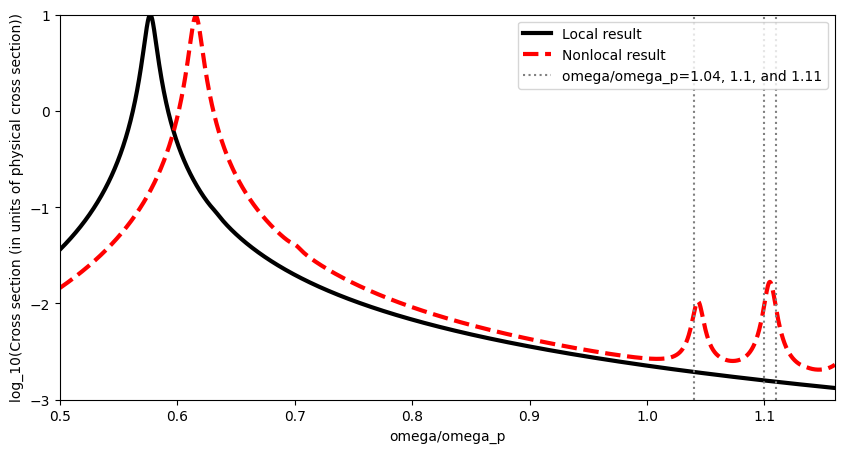

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(omegas, np.log10(cross_sections_local), color="black", linestyle="solid", linewidth=3, label="Local result")
ax.plot(omegas, np.log10(cross_sections_non_local), color="red", linestyle="dashed", linewidth=3, label="Nonlocal result")
ax.set_yticks([-3, -2, -1, 0, 1]);
ax.set_ylim(-3, 1)
ax.set_xlabel("omega/omega_p");
ax.set_ylabel("log_10(Cross section (in units of physical cross section))")
ax.vlines([1.04], -3, 1, linestyle="dotted", color="Grey")
ax.vlines([1.1], -3, 1, linestyle="dotted", color="Grey")
ax.vlines([1.11], -3, 1, linestyle="dotted", color="Grey", label="omega/omega_p=1.04, 1.1, and 1.11")
ax.legend();
#ax.hlines([np.log10(0.02)], 0.5, 1.16)
ax.set_xlim(0.5, 1.16);